# Monte Carlo Option Pricing

A walkthrough of pricing European options by Monte Carlo simulation under the
Black-Scholes-Merton model — deriving the simulation scheme, checking it
against the closed-form price, applying variance reduction, studying
convergence, and estimating Greeks.

This notebook is a narrative companion to the tested library in
[`../src/mc_option_pricing`](../src/mc_option_pricing); see the
[project README](../README.md) for the package API and test suite.

## 1. Theory

### Risk-neutral pricing

Under the risk-neutral measure $\mathbb{Q}$, the no-arbitrage price of a
European option with payoff $h(S_T)$ at maturity $T$ is the discounted
expected payoff:

$$
V_0 = e^{-rT}\, \mathbb{E}^{\mathbb{Q}}\big[h(S_T)\big]
$$

Monte Carlo pricing replaces this expectation with a sample mean over $N$
simulated draws of $S_T$:

$$
\hat V_0 = e^{-rT} \cdot \frac{1}{N}\sum_{i=1}^N h\big(S_T^{(i)}\big)
$$

By the law of large numbers $\hat V_0 \to V_0$ as $N \to \infty$, and by the
central limit theorem the estimator's standard error shrinks as
$O(N^{-1/2})$ — the convergence rate we'll check empirically below.

### Geometric Brownian motion

The underlying is assumed to follow

$$
dS_t = r S_t\, dt + \sigma S_t\, dW_t
$$

which has the closed-form (exact, not discretized) solution

$$
S_T = S_0 \exp\!\left(\left(r - \tfrac{1}{2}\sigma^2\right) T + \sigma \sqrt{T}\, Z\right),
\qquad Z \sim \mathcal N(0, 1)
$$

Because a European payoff depends only on $S_T$, we can draw it in a single
step — no need to simulate the intermediate path.

## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import lognorm

from mc_option_pricing import bs_price, bs_greeks, mc_price, mc_greeks, simulate_terminal_prices

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

# Market / contract parameters used throughout this notebook
S0, K, r, sigma, T = 100.0, 105.0, 0.03, 0.25, 1.0
OPTION_TYPE = "call"

print(f"S0={S0}  K={K}  r={r}  sigma={sigma}  T={T}  option={OPTION_TYPE}")

S0=100.0  K=105.0  r=0.03  sigma=0.25  T=1.0  option=call


## 3. Simulating the terminal distribution

$S_T$ is lognormally distributed under GBM. Before pricing anything, let's
confirm the simulator reproduces the correct distribution by overlaying a
histogram of simulated draws against the analytic lognormal density.

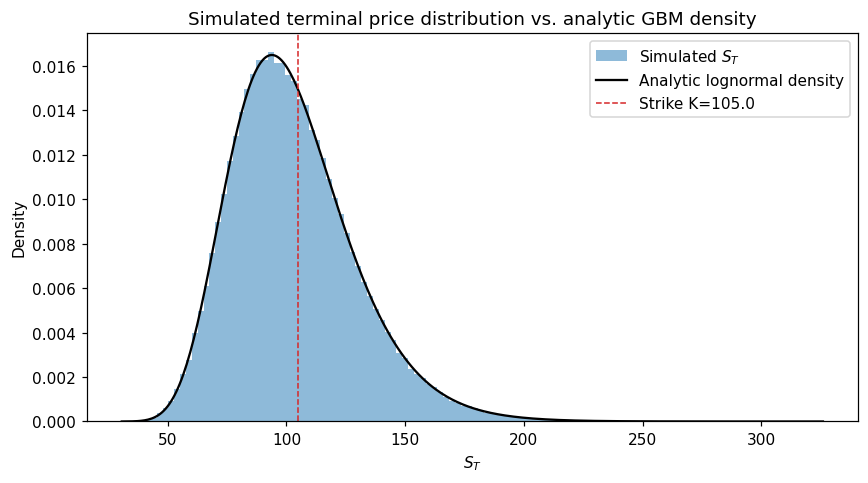

Simulated mean:  103.0467
Theoretical mean: 103.0455   (= S0 * exp(rT), the risk-neutral forward price)


In [2]:
rng = np.random.default_rng(0)
S_T = simulate_terminal_prices(S0, r, sigma, T, n_paths=200_000, antithetic=True, rng=rng)

# Analytic lognormal density of S_T under GBM
mu = np.log(S0) + (r - 0.5 * sigma**2) * T
s = sigma * np.sqrt(T)
x = np.linspace(S_T.min(), S_T.max(), 400)
pdf = lognorm.pdf(x, s=s, scale=np.exp(mu))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(S_T, bins=120, density=True, alpha=0.5, color="#1f77b4", label="Simulated $S_T$")
ax.plot(x, pdf, color="black", lw=1.5, label="Analytic lognormal density")
ax.axvline(K, color="#d62728", linestyle="--", lw=1, label=f"Strike K={K}")
ax.set_xlabel("$S_T$")
ax.set_ylabel("Density")
ax.set_title("Simulated terminal price distribution vs. analytic GBM density")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Simulated mean:  {S_T.mean():.4f}")
print(f"Theoretical mean: {S0 * np.exp(r * T):.4f}   (= S0 * exp(rT), the risk-neutral forward price)")

## 4. Crude Monte Carlo pricing

Price the option with a plain (non-antithetic) Monte Carlo estimator and
compare it to the closed-form Black-Scholes price.

In [3]:
bs = bs_price(S0, K, r, sigma, T, OPTION_TYPE)
crude = mc_price(S0, K, r, sigma, T, OPTION_TYPE, n_paths=200_000, antithetic=False, seed=42)

print(f"Black-Scholes price:        {bs:.4f}")
print(f"Crude Monte Carlo price:    {crude.price:.4f}  (std err {crude.std_error:.4f})")
print(f"95% confidence interval:    [{crude.ci_95[0]:.4f}, {crude.ci_95[1]:.4f}]")
print(f"Absolute error vs BS:       {abs(crude.price - bs):.4f}")

Black-Scholes price:        9.1218
Crude Monte Carlo price:    9.1509  (std err 0.0368)
95% confidence interval:    [9.0787, 9.2231]
Absolute error vs BS:       0.0291


## 5. Variance reduction: antithetic variates

Each standard normal draw $Z$ is paired with its mirror image $-Z$. Since
$S_T(Z)$ and $S_T(-Z)$ are negatively correlated and a call payoff is
monotonic in $S_T$, averaging the pair cancels a first-order share of the
simulation noise — for the *same* number of paths, the antithetic estimator
should have a visibly smaller standard error.

In [4]:
N = 200_000
plain = mc_price(S0, K, r, sigma, T, OPTION_TYPE, n_paths=N, antithetic=False, seed=7)
anti = mc_price(S0, K, r, sigma, T, OPTION_TYPE, n_paths=N, antithetic=True, seed=7)

reduction = 1 - (anti.std_error / plain.std_error) ** 2

comparison = pd.DataFrame(
    {
        "price": [plain.price, anti.price],
        "std_error": [plain.std_error, anti.std_error],
        "ci_width": [plain.ci_95[1] - plain.ci_95[0], anti.ci_95[1] - anti.ci_95[0]],
    },
    index=["crude", "antithetic"],
)
display(comparison)
print(f"\nVariance reduced by ~{reduction:.1%} at the same path count (N={N:,}).")

,price,std_error,ci_width
crude,9.118427,0.036508,0.143110
antithetic,9.092729,0.036478,0.142992



Variance reduced by ~0.2% at the same path count (N=200,000).


## 6. Convergence analysis

Two things to check as $N$ grows:

1. The Monte Carlo price converges to the Black-Scholes price, with its
   confidence interval tightening around it.
2. The standard error shrinks at the theoretical $O(N^{-1/2})$ rate — visible
   as a straight line of slope $-\tfrac12$ on a log-log plot.

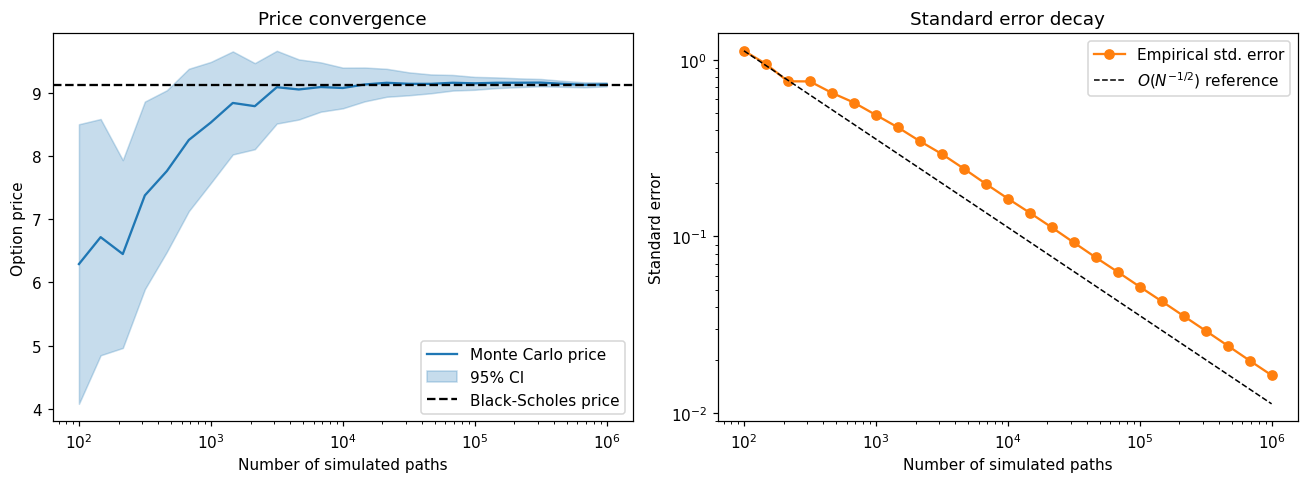

In [5]:
path_counts = np.unique(np.logspace(2, 6, 25).astype(int))

prices, std_errors = [], []
for n in path_counts:
    result = mc_price(S0, K, r, sigma, T, OPTION_TYPE, n_paths=int(n), antithetic=True, seed=42)
    prices.append(result.price)
    std_errors.append(result.std_error)

prices = np.array(prices)
std_errors = np.array(std_errors)
half_widths = 1.96 * std_errors

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(path_counts, prices, color="#1f77b4", label="Monte Carlo price")
ax.fill_between(path_counts, prices - half_widths, prices + half_widths,
                 alpha=0.25, color="#1f77b4", label="95% CI")
ax.axhline(bs, color="black", linestyle="--", label="Black-Scholes price")
ax.set_xscale("log")
ax.set_xlabel("Number of simulated paths")
ax.set_ylabel("Option price")
ax.set_title("Price convergence")
ax.legend()

ax = axes[1]
ax.loglog(path_counts, std_errors, "o-", color="#ff7f0e", label="Empirical std. error")
reference = std_errors[0] * np.sqrt(path_counts[0] / path_counts)
ax.loglog(path_counts, reference, "k--", lw=1, label=r"$O(N^{-1/2})$ reference")
ax.set_xlabel("Number of simulated paths")
ax.set_ylabel("Standard error")
ax.set_title("Standard error decay")
ax.legend()

fig.tight_layout()
plt.show()

## 7. Greeks via finite differences

`mc_greeks` estimates each Greek by central finite differences
(bump-and-reprice), reusing the same random seed across the bumped and base
scenarios (common random numbers) so the *difference* is driven by the bump
itself rather than by fresh simulation noise.

,Black-Scholes,Monte Carlo,abs. diff
delta,0.519875,0.520206,0.000332
gamma,0.015938,0.016081,0.000143
vega,39.844711,40.093919,0.249208
theta,-6.266559,-6.297762,0.031203
rho,42.865680,42.867493,0.001813


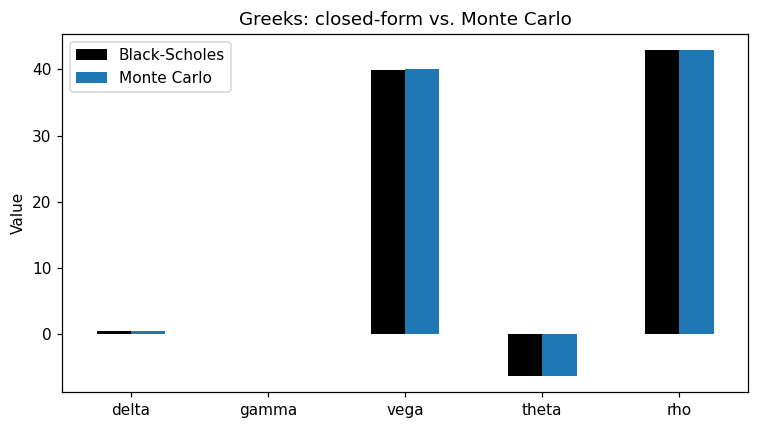

In [6]:
bs_g = bs_greeks(S0, K, r, sigma, T, OPTION_TYPE)
mc_g = mc_greeks(S0, K, r, sigma, T, OPTION_TYPE, n_paths=300_000, seed=42)

greeks_df = pd.DataFrame({"Black-Scholes": bs_g, "Monte Carlo": mc_g})
greeks_df["abs. diff"] = (greeks_df["Black-Scholes"] - greeks_df["Monte Carlo"]).abs()
display(greeks_df)

fig, ax = plt.subplots(figsize=(7, 4))
greeks_df[["Black-Scholes", "Monte Carlo"]].plot.bar(ax=ax, color=["black", "#1f77b4"])
ax.set_title("Greeks: closed-form vs. Monte Carlo")
ax.set_ylabel("Value")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

## 8. Sensitivity: price vs. strike and volatility

As a final check, sweep the strike and volatility over a range and confirm
the Monte Carlo price tracks the closed-form curve everywhere, not just at
the single parameter set used above.

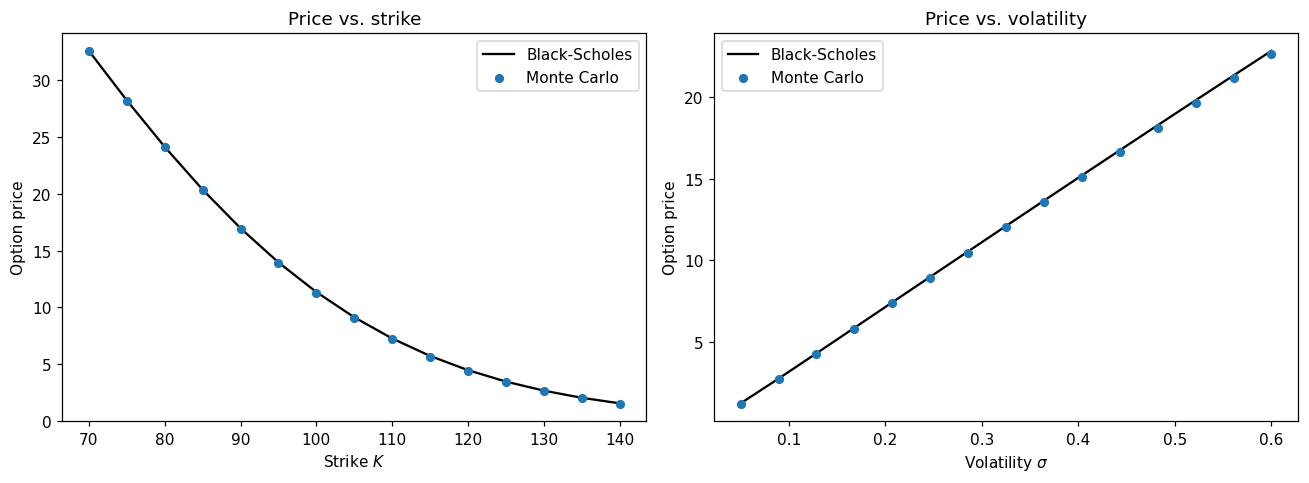

In [7]:
strikes = np.linspace(70, 140, 15)
vols = np.linspace(0.05, 0.6, 15)

bs_by_strike = [bs_price(S0, k, r, sigma, T, OPTION_TYPE) for k in strikes]
mc_by_strike = [mc_price(S0, k, r, sigma, T, OPTION_TYPE, n_paths=100_000, seed=1).price for k in strikes]

bs_by_vol = [bs_price(S0, K, r, v, T, OPTION_TYPE) for v in vols]
mc_by_vol = [mc_price(S0, K, r, v, T, OPTION_TYPE, n_paths=100_000, seed=1).price for v in vols]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(strikes, bs_by_strike, color="black", label="Black-Scholes")
ax.scatter(strikes, mc_by_strike, color="#1f77b4", s=25, zorder=3, label="Monte Carlo")
ax.set_xlabel("Strike $K$")
ax.set_ylabel("Option price")
ax.set_title("Price vs. strike")
ax.legend()

ax = axes[1]
ax.plot(vols, bs_by_vol, color="black", label="Black-Scholes")
ax.scatter(vols, mc_by_vol, color="#1f77b4", s=25, zorder=3, label="Monte Carlo")
ax.set_xlabel(r"Volatility $\sigma$")
ax.set_ylabel("Option price")
ax.set_title("Price vs. volatility")
ax.legend()

fig.tight_layout()
plt.show()

## 9. Conclusion

- Monte Carlo simulation reproduces the closed-form Black-Scholes price and
  Greeks across a range of strikes and volatilities, with the standard error
  decaying at the expected $O(N^{-1/2})$ rate.
- Antithetic variates cut variance meaningfully at no extra simulation cost,
  and common random numbers make finite-difference Greeks stable enough to
  be usable.
- The real payoff of Monte Carlo is generality: because pricing only
  requires the ability to *simulate* the underlying and evaluate a payoff,
  the same machinery extends to path-dependent payoffs (Asian, barrier),
  richer dynamics (stochastic volatility, jumps), and multiple correlated
  assets — cases where closed-form solutions like Black-Scholes usually
  don't exist.

See the [project README](../README.md) for the tested library API and the
plain-script version of this analysis in
[`examples/run_example.py`](../examples/run_example.py).